<a href="https://colab.research.google.com/github/GauriNair05/Customer-Segmentation-Using-K-Means-Clustering-and-PCA/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

First 5 records:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


Numerical Features: ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Categorical Features: ['Genre']


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 

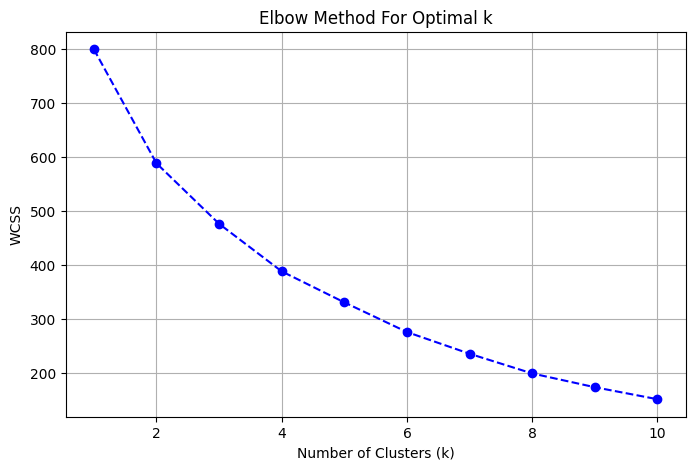

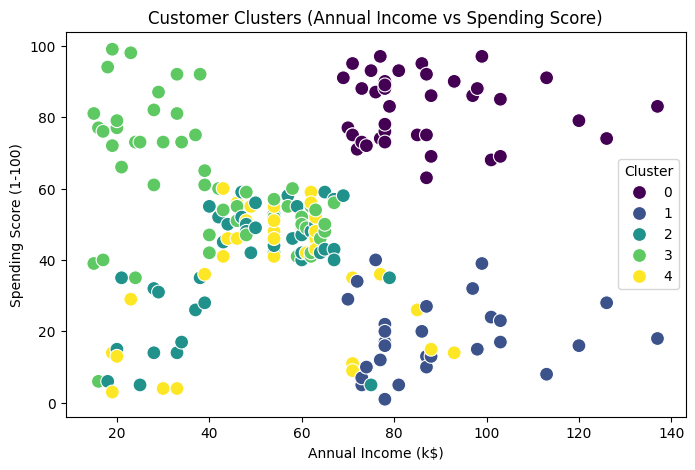

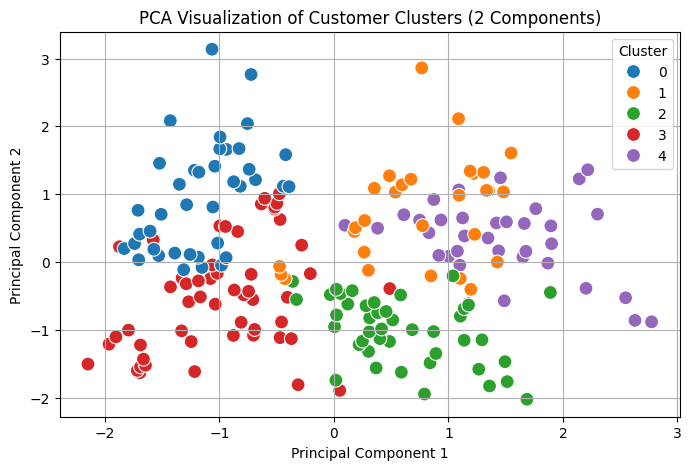

In [3]:
url = "https://raw.githubusercontent.com/sharmaroshan/Clustering-of-Mall-Customers/master/Mall_Customers.csv"
df = pd.read_csv(url)

print("First 5 records:")
print(df.head())
print("\n" + "="*50 + "\n")

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)
print("\n" + "="*50 + "\n")

print("Dataset Info:")
df.info()
print("\nSummary Statistics:")
print(df.describe(include='all'))
print("\n" + "="*50 + "\n")

print("Missing Values:")
print(df.isnull().sum())

df_clean = df.drop(columns=['CustomerID'])

le = LabelEncoder()
df_clean['Genre'] = le.fit_transform(df_clean['Genre']) if 'Genre' in df_clean.columns else le.fit_transform(df_clean['Gender'])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_clean)
df_scaled = pd.DataFrame(scaled_features, columns=df_clean.columns)

wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df_scaled)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='viridis',
    s=100
)
plt.title('Customer Clusters (Annual Income vs Spending Score)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()

pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_scaled)

pca_df = pd.DataFrame(pca_features, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = df['Cluster']

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_df,
    palette='tab10',
    s=100
)
plt.title('PCA Visualization of Customer Clusters (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()